## Creating Gradient Descent Regressor Class

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
X, y = make_regression(n_samples=200, n_features=1, n_informative=1, n_targets=1, noise=23, random_state=2)

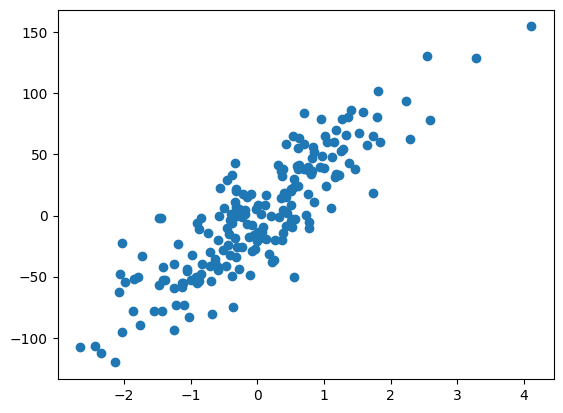

In [3]:
plt.scatter(X,y)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 3)

In [18]:
lr = LinearRegression()

In [19]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
display(lr.coef_)
display(lr.intercept_)

array([39.04241352])

np.float64(0.14868454344616433)

In [ ]:
from sklearn.metrics import r2_score

y_pred = lr.predict(X_test)
r2_score(y_pred, y_test)

0.5114658822200377

In [30]:
class GDreg:
  def __init__(self, lerning_rate, epochs):
    self.m = 120
    self.b = -140
    self.lr = lerning_rate
    self.epochs = epochs
    
  def fit(self,X,y):
    # calculate B useing gradient descent
    
    for i in range(self.epochs):
      loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
      loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b) * X.ravel())
      
      self.b = self.b - (self.lr * loss_slope_b)
      self.m = self.m - (self.lr * loss_slope_m)
      
    print(self.m,self.b)
    
  def predict(self,X):
    return self.m * X + self.b 

In [31]:
gd = GDreg(0.001,50)

In [32]:
gd.fit(X_train,y_train)

39.04241356707876 0.14868391272083273


In [33]:
y_pred = gd.predict(X_test)

r2_score(y_pred, y_test)

0.5114658854583362